# Problem 14: AdaBoost Classification - Binary Classification Problem

**Objective**: Implement AdaBoost (Adaptive Boosting) classifier to solve a binary classification problem. Train the model and evaluate its accuracy, precision, recall, and F1 score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_score, recall_score, f1_score
import joblib
import os

# Set random seed for reproducibility
np.random.seed(42)

# Create synthetic dataset - Credit Card Fraud Detection
n_samples = 400
n_features = 4

# Generate features
transaction_amount = np.random.uniform(10, 5000, n_samples)
transaction_frequency = np.random.uniform(1, 100, n_samples)
time_since_last_transaction = np.random.uniform(0, 30, n_samples)
unusual_location = np.random.uniform(0, 1, n_samples)

# Create target: fraud (1) or legitimate (0)
fraud = np.zeros(n_samples)
fraud_indices = np.random.choice(n_samples, size=int(0.3 * n_samples), replace=False)
fraud[fraud_indices] = 1

# Add some pattern to features for fraudulent transactions
fraud_mask = fraud == 1
transaction_amount[fraud_mask] = np.random.uniform(2000, 5000, fraud_mask.sum())
unusual_location[fraud_mask] = np.random.uniform(0.5, 1, fraud_mask.sum())

# Create DataFrame
df = pd.DataFrame({
    'transaction_amount': transaction_amount,
    'transaction_frequency': transaction_frequency,
    'time_since_last_transaction': time_since_last_transaction,
    'unusual_location': unusual_location,
    'fraud': fraud
})

# Save to CSV
csv_path = 'fraud_detection.csv'
df.to_csv(csv_path, index=False)
print(f"Dataset created: {csv_path}")
print(f"Dataset shape: {df.shape}")
print(f"Fraud distribution:")
print(df['fraud'].value_counts())

Dataset created: fraud_detection.csv
Dataset shape: (400, 5)
Fraud distribution:
fraud
0.0    280
1.0    120
Name: count, dtype: int64


In [2]:
# Load and display dataset overview
df = pd.read_csv('fraud_detection.csv')

print("Dataset Overview:")
print(df.head())
print(f"\nDataset Shape: {df.shape}")
print(f"\nDataset Info:")
print(df.info())
print(f"\nDataset Statistics:")
print(df.describe())

Dataset Overview:
   transaction_amount  transaction_frequency  time_since_last_transaction  \
0         3662.679542              11.209263                    21.217159   
1         2015.688841              90.352738                     4.576171   
2         3662.649770              51.019985                    17.288651   
3         2997.305836              82.819289                    18.201451   
4          788.533016              32.684911                    12.723920   

   unusual_location  fraud  
0          0.981697    1.0  
1          0.780084    1.0  
2          0.022124    0.0  
3          0.323610    0.0  
4          0.488643    0.0  

Dataset Shape: (400, 5)

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   transaction_amount           400 non-null    float64
 1   transaction_frequency        400 

## Data Cleaning

Check for missing values, duplicates, and data type consistency.

In [3]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for duplicates
print(f"\nDuplicate rows: {df.duplicated().sum()}")

# Check data types
print(f"\nData types:")
print(df.dtypes)

# Check class distribution
print(f"\nClass distribution:")
print(df['fraud'].value_counts())
print(f"\nClass ratio:")
print(df['fraud'].value_counts(normalize=True))

# Remove any duplicates (if present)
df = df.drop_duplicates().reset_index(drop=True)
print(f"\nDataset shape after cleaning: {df.shape}")

Missing values:
transaction_amount             0
transaction_frequency          0
time_since_last_transaction    0
unusual_location               0
fraud                          0
dtype: int64

Duplicate rows: 0

Data types:
transaction_amount             float64
transaction_frequency          float64
time_since_last_transaction    float64
unusual_location               float64
fraud                          float64
dtype: object

Class distribution:
fraud
0.0    280
1.0    120
Name: count, dtype: int64

Class ratio:
fraud
0.0    0.7
1.0    0.3
Name: proportion, dtype: float64

Dataset shape after cleaning: (400, 5)


## Exploratory Data Analysis (EDA)

Visualize the relationships between features and fraud classification.

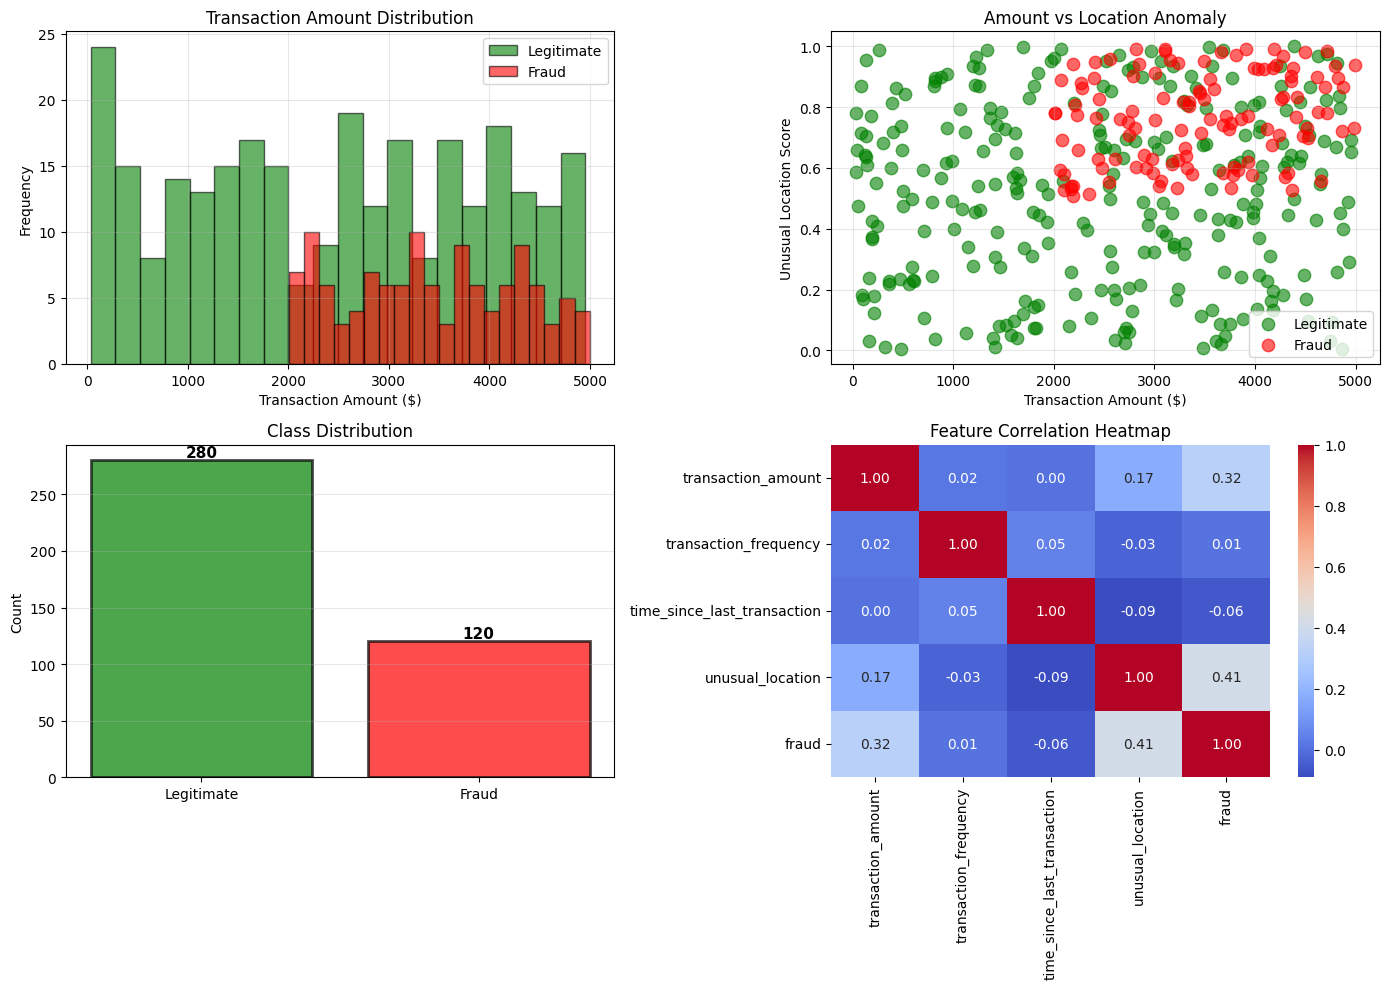

Feature Statistics:
       transaction_amount  transaction_frequency  time_since_last_transaction  \
count          400.000000             400.000000                   400.000000   
mean          2745.638284              50.472475                    15.106637   
std           1390.283246              29.086121                     8.904990   
min             35.257303               2.072927                     0.138961   
25%           1654.321981              24.942527                     6.979126   
50%           2895.897312              50.803814                    15.566336   
75%           3903.317254              76.294307                    22.935043   
max           4995.042534              99.972050                    29.938023   

       unusual_location       fraud  
count        400.000000  400.000000  
mean           0.588068    0.300000  
std            0.279512    0.458831  
min            0.004940    0.000000  
25%            0.397239    0.000000  
50%            0.62687

In [4]:
# Create visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Class labels
class_names = ['Legitimate', 'Fraud']
colors = ['green', 'red']

# Plot 1: Transaction Amount Distribution by Class
for i, (cls, color) in enumerate(zip([0, 1], colors)):
    mask = df['fraud'] == cls
    axes[0, 0].hist(df[mask]['transaction_amount'], bins=20, label=class_names[i], 
                    alpha=0.6, color=color, edgecolor='black')
axes[0, 0].set_xlabel('Transaction Amount ($)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Transaction Amount Distribution')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Plot 2: Scatter - Transaction Amount vs Unusual Location
for i, (cls, color) in enumerate(zip([0, 1], colors)):
    mask = df['fraud'] == cls
    axes[0, 1].scatter(df[mask]['transaction_amount'], df[mask]['unusual_location'],
                      label=class_names[i], alpha=0.6, color=color, s=80)
axes[0, 1].set_xlabel('Transaction Amount ($)')
axes[0, 1].set_ylabel('Unusual Location Score')
axes[0, 1].set_title('Amount vs Location Anomaly')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Plot 3: Class Distribution
class_counts = df['fraud'].value_counts()
bars = axes[1, 0].bar(class_names, [class_counts[0], class_counts[1]], 
                       color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('Class Distribution')
axes[1, 0].grid(True, alpha=0.3, axis='y')
for bar, count in zip(bars, [class_counts[0], class_counts[1]]):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, count, str(count),
                   ha='center', va='bottom', fontsize=11, weight='bold')

# Plot 4: Correlation heatmap
correlation = df.corr()
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1, 1], cbar=True)
axes[1, 1].set_title('Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

print(f"Feature Statistics:")
print(df.describe())

## Feature Scaling

Normalize features using StandardScaler for optimal model performance.

In [5]:
# Separate features and target
X = df[['transaction_amount', 'transaction_frequency', 'time_since_last_transaction', 'unusual_location']].values
y = df['fraud'].values

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed")
print(f"X shape: {X_scaled.shape}")
print(f"y shape: {y.shape}")
print(f"\nScaled feature statistics:")
print(f"X mean: {X_scaled.mean():.4f}, std: {X_scaled.std():.4f}")
print(f"Number of classes: {len(np.unique(y))}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

Feature scaling completed
X shape: (400, 4)
y shape: (400,)

Scaled feature statistics:
X mean: -0.0000, std: 1.0000
Number of classes: 2
Class distribution: [280 120]


## Theory: AdaBoost (Adaptive Boosting)

**AdaBoost** is a boosting ensemble algorithm that combines weak learners sequentially to create a strong classifier.

### Key Concepts:
- **Weak Learner**: Base learner (typically shallow decision tree) with accuracy slightly better than random
- **Sequential Learning**: Each new learner focuses on misclassified samples from previous learners
- **Sample Weights**: Samples are re-weighted; hard-to-classify samples get higher weights
- **Weighted Voting**: Final prediction is a weighted majority vote from all learners

### Algorithm Steps:
1. Initialize sample weights uniformly: $w_i = \frac{1}{n}$
2. For each iteration $t = 1, 2, ..., T$:
   - Train weak learner on weighted data
   - Calculate weighted error $\epsilon_t$
   - Calculate learner weight $\alpha_t = \frac{1}{2} \ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$
   - Update sample weights for next iteration
3. Final prediction: weighted majority vote

### Advantages:
- Reduces bias and variance of weak learners
- Often outperforms individual models significantly
- Resistant to overfitting
- No hyperparameter tuning needed (robust defaults)

### Disadvantages:
- Sensitive to noise and outliers
- Slower training than single learner
- Less interpretable than individual models

## Mathematical Representation

AdaBoost ensemble prediction:

**Final Classifier**:
$$f(x) = \text{sign}\left(\sum_{t=1}^{T} \alpha_t h_t(x)\right)$$

where:
- $h_t(x)$ = prediction from $t$-th weak learner
- $\alpha_t$ = weight of $t$-th learner

**Learner Weight**:
$$\alpha_t = \frac{1}{2} \ln\left(\frac{1-\epsilon_t}{\epsilon_t}\right)$$

where $\epsilon_t$ is the weighted error of learner $t$:
$$\epsilon_t = \sum_{i: h_t(x_i) \neq y_i} w_i^{(t)}$$

**Sample Weight Update**:
$$w_i^{(t+1)} = \frac{w_i^{(t)} \exp(-\alpha_t y_i h_t(x_i))}{Z_t}$$

where $Z_t$ is a normalization factor.

## Workflow Diagram

Visualize the complete AdaBoost pipeline.

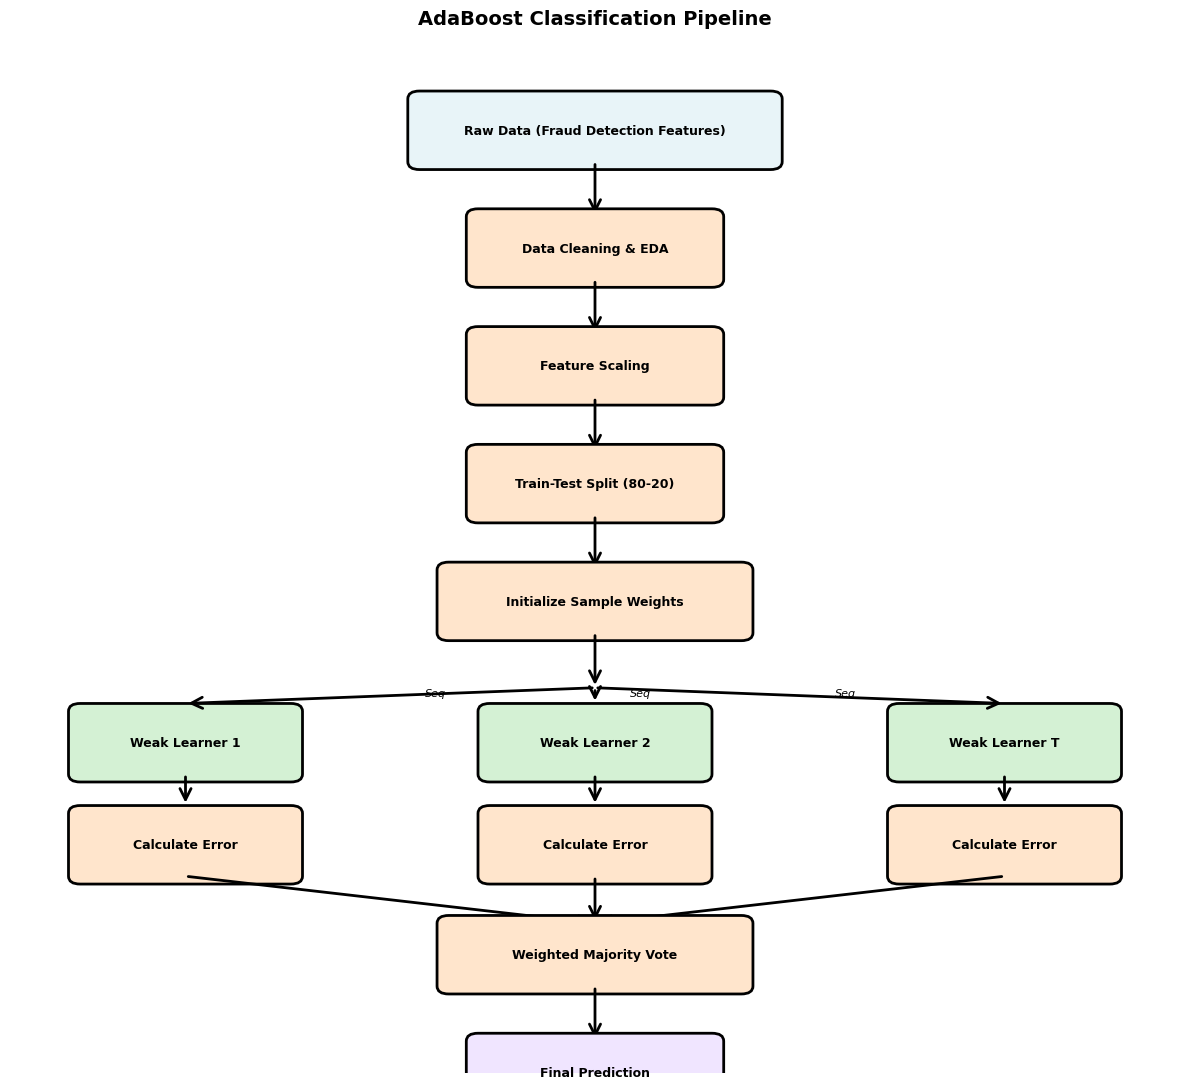

In [6]:
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

fig, ax = plt.subplots(1, 1, figsize=(12, 11))
ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis('off')

# Define colors
color_input = '#E8F4F8'
color_process = '#FFE5CC'
color_model = '#D4F1D4'
color_output = '#F0E5FF'

# Helper function to create boxes
def add_box(ax, x, y, width, height, text, color):
    box = FancyBboxPatch((x - width/2, y - height/2), width, height,
                         boxstyle="round,pad=0.1", 
                         edgecolor='black', facecolor=color, linewidth=2)
    ax.add_patch(box)
    ax.text(x, y, text, ha='center', va='center', fontsize=9, weight='bold', wrap=True)

# Helper function to create arrows
def add_arrow(ax, x1, y1, x2, y2, label=''):
    arrow = FancyArrowPatch((x1, y1), (x2, y2),
                           arrowstyle='->', mutation_scale=20, 
                           linewidth=2, color='black')
    ax.add_patch(arrow)
    if label:
        mid_x, mid_y = (x1 + x2) / 2, (y1 + y2) / 2
        ax.text(mid_x + 0.3, mid_y, label, fontsize=8, style='italic')

# Create workflow
add_box(ax, 5, 12, 3, 0.8, 'Raw Data (Fraud Detection Features)', color_input)
add_arrow(ax, 5, 11.6, 5, 10.9)

add_box(ax, 5, 10.5, 2, 0.8, 'Data Cleaning & EDA', color_process)
add_arrow(ax, 5, 10.1, 5, 9.4)

add_box(ax, 5, 9, 2, 0.8, 'Feature Scaling', color_process)
add_arrow(ax, 5, 8.6, 5, 7.9)

add_box(ax, 5, 7.5, 2, 0.8, 'Train-Test Split (80-20)', color_process)
add_arrow(ax, 5, 7.1, 5, 6.4)

add_box(ax, 5, 6, 2.5, 0.8, 'Initialize Sample Weights', color_process)
add_arrow(ax, 5, 5.6, 5, 4.9)

# Sequential boosting loop
add_box(ax, 1.5, 4.2, 1.8, 0.8, 'Weak Learner 1', color_model)
add_box(ax, 5, 4.2, 1.8, 0.8, 'Weak Learner 2', color_model)
add_box(ax, 8.5, 4.2, 1.8, 0.8, 'Weak Learner T', color_model)

add_arrow(ax, 5, 4.9, 1.5, 4.7, 'Seq')
add_arrow(ax, 5, 4.9, 5, 4.7, 'Seq')
add_arrow(ax, 5, 4.9, 8.5, 4.7, 'Seq')

# Error calculation and weight update
add_box(ax, 1.5, 2.9, 1.8, 0.8, 'Calculate Error', color_process)
add_box(ax, 5, 2.9, 1.8, 0.8, 'Calculate Error', color_process)
add_box(ax, 8.5, 2.9, 1.8, 0.8, 'Calculate Error', color_process)

add_arrow(ax, 1.5, 3.8, 1.5, 3.4)
add_arrow(ax, 5, 3.8, 5, 3.4)
add_arrow(ax, 8.5, 3.8, 8.5, 3.4)

# Update weights
add_arrow(ax, 1.5, 2.5, 5, 1.9)
add_arrow(ax, 5, 2.5, 5, 1.9)
add_arrow(ax, 8.5, 2.5, 5, 1.9)

add_box(ax, 5, 1.5, 2.5, 0.8, 'Weighted Majority Vote', color_process)
add_arrow(ax, 5, 1.1, 5, 0.4)

add_box(ax, 5, 0, 2, 0.8, 'Final Prediction', color_output)

plt.title('AdaBoost Classification Pipeline', fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

## Pseudocode

```
ALGORITHM: AdaBoost Classifier
INPUT: Features (X), Labels (y)

1. DATA PREPARATION
   - Load fraud detection dataset
   - Clean data: remove missing values and duplicates
   - Perform EDA: visualize feature relationships

2. FEATURE SCALING
   - Apply StandardScaler to all features

3. TRAIN-TEST SPLIT
   - Split data: 80% training, 20% testing

4. AdaBoost INITIALIZATION
   - Base estimator: DecisionTreeClassifier (max_depth=1)
   - Number of estimators: 50
   - Learning rate: 1.0 (controls influence of each learner)
   - Initialize sample weights: w_i = 1/n

5. SEQUENTIAL BOOSTING
   FOR t = 1 to n_estimators:
      - Train weak learner on weighted training data
      - Predict on training set
      - Calculate weighted error: ε_t
      - Calculate learner weight: α_t = 0.5 * ln((1-ε_t)/ε_t)
      - Update sample weights for next iteration
      - Store model and weight

6. PREDICTION
   FOR each test sample:
      - Get predictions from all weak learners
      - Compute weighted sum: Σ(α_t * h_t(x))
      - Return sign (positive/negative) of sum

7. EVALUATION
   - Calculate accuracy on test set
   - Generate confusion matrix
   - Calculate precision, recall, F1 score
   - Extract feature importance

8. MODEL PERSISTENCE
   - Save AdaBoost model and scaler
```

## Train-Test Split

Split the data into training and testing sets (80-20 split).

In [7]:
# Split the data into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")
print(f"\nTraining set shape: X_train {X_train.shape}, y_train {y_train.shape}")
print(f"Testing set shape: X_test {X_test.shape}, y_test {y_test.shape}")
print(f"\nClass distribution in training set: {np.bincount(y_train.astype(int))}")
print(f"Class distribution in test set: {np.bincount(y_test.astype(int))}")

Training set size: 320
Testing set size: 80

Training set shape: X_train (320, 4), y_train (320,)
Testing set shape: X_test (80, 4), y_test (80,)

Class distribution in training set: [224  96]
Class distribution in test set: [56 24]


## AdaBoost Model Training

Train AdaBoost classifier with decision trees as base estimator.

In [8]:
# Create AdaBoost classifier
adaboost_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1, random_state=42),
    n_estimators=50,            # Number of weak learners
    learning_rate=1.0,          # Controls influence of each weak learner
    random_state=42
)

# Train the model
adaboost_model.fit(X_train, y_train)

print("AdaBoost Model trained successfully!")
print(f"\nModel Configuration:")
print(f"  Base Estimator: Decision Tree (max_depth=1, decision stump)")
print(f"  Number of Estimators: {adaboost_model.n_estimators}")
print(f"  Learning Rate: {adaboost_model.learning_rate}")
print(f"  Random State: 42")

AdaBoost Model trained successfully!

Model Configuration:
  Base Estimator: Decision Tree (max_depth=1, decision stump)
  Number of Estimators: 50
  Learning Rate: 1.0
  Random State: 42


## Making Predictions

Generate predictions on the test set.

In [9]:
# Make predictions on test set
y_pred = adaboost_model.predict(X_test)

# Get prediction probabilities
y_pred_proba = adaboost_model.predict_proba(X_test)

print("Predictions made successfully!")
print(f"\nFirst 10 predictions:")
print(f"{'True':>6} | {'Predicted':>11} | {'Confidence':>12}")
print("-" * 32)
for i in range(min(10, len(y_test))):
    confidence = np.max(y_pred_proba[i])
    class_name = 'Fraud' if y_pred[i] == 1 else 'Legitimate'
    print(f"{int(y_test[i]):>6} | {class_name:>11} | {confidence:>11.2%}")

Predictions made successfully!

First 10 predictions:
  True |   Predicted |   Confidence
--------------------------------
     0 |  Legitimate |      72.45%
     0 |  Legitimate |      72.45%
     1 |       Fraud |      51.34%
     1 |       Fraud |      53.69%
     1 |       Fraud |      51.34%
     0 |  Legitimate |      70.79%
     0 |       Fraud |      51.34%
     0 |       Fraud |      51.34%
     1 |       Fraud |      51.34%
     0 |       Fraud |      51.34%


## Evaluation Metrics: Accuracy and More

Calculate and display accuracy, precision, recall, and F1 score.

In [10]:
# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

# Per-class metrics
precision_per_class = precision_score(y_test, y_pred, average=None)
recall_per_class = recall_score(y_test, y_pred, average=None)
f1_per_class = f1_score(y_test, y_pred, average=None)

print("="*70)
print("ADABOOST CLASSIFIER - EVALUATION METRICS")
print("="*70)
print(f"\nOverall Performance:")
print(f"  Accuracy (overall):           {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"  Precision (weighted):         {precision:.6f}")
print(f"  Recall (weighted):            {recall:.6f}")
print(f"  F1 Score (weighted):          {f1:.6f}")

print(f"\nConfusion Matrix:")
print(conf_matrix)
print(f"\nTrue Negatives (TN):          {conf_matrix[0,0]}")
print(f"False Positives (FP):         {conf_matrix[0,1]}")
print(f"False Negatives (FN):         {conf_matrix[1,0]}")
print(f"True Positives (TP):          {conf_matrix[1,1]}")

print(f"\nPer-Class Metrics:")
print(f"  Class 0 (Legitimate):")
print(f"    Precision: {precision_per_class[0]:.6f}")
print(f"    Recall: {recall_per_class[0]:.6f}")
print(f"    F1 Score: {f1_per_class[0]:.6f}")
print(f"  Class 1 (Fraud):")
print(f"    Precision: {precision_per_class[1]:.6f}")
print(f"    Recall: {recall_per_class[1]:.6f}")
print(f"    F1 Score: {f1_per_class[1]:.6f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Legitimate', 'Fraud']))
print("="*70)

ADABOOST CLASSIFIER - EVALUATION METRICS

Overall Performance:
  Accuracy (overall):           0.775000 (77.50%)
  Precision (weighted):         0.840351
  Recall (weighted):            0.775000
  F1 Score (weighted):          0.784332

Confusion Matrix:
[[40 16]
 [ 2 22]]

True Negatives (TN):          40
False Positives (FP):         16
False Negatives (FN):         2
True Positives (TP):          22

Per-Class Metrics:
  Class 0 (Legitimate):
    Precision: 0.952381
    Recall: 0.714286
    F1 Score: 0.816327
  Class 1 (Fraud):
    Precision: 0.578947
    Recall: 0.916667
    F1 Score: 0.709677

Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       0.95      0.71      0.82        56
       Fraud       0.58      0.92      0.71        24

    accuracy                           0.78        80
   macro avg       0.77      0.82      0.76        80
weighted avg       0.84      0.78      0.78        80



## Confusion Matrix Visualization

Visualize the confusion matrix heatmap.

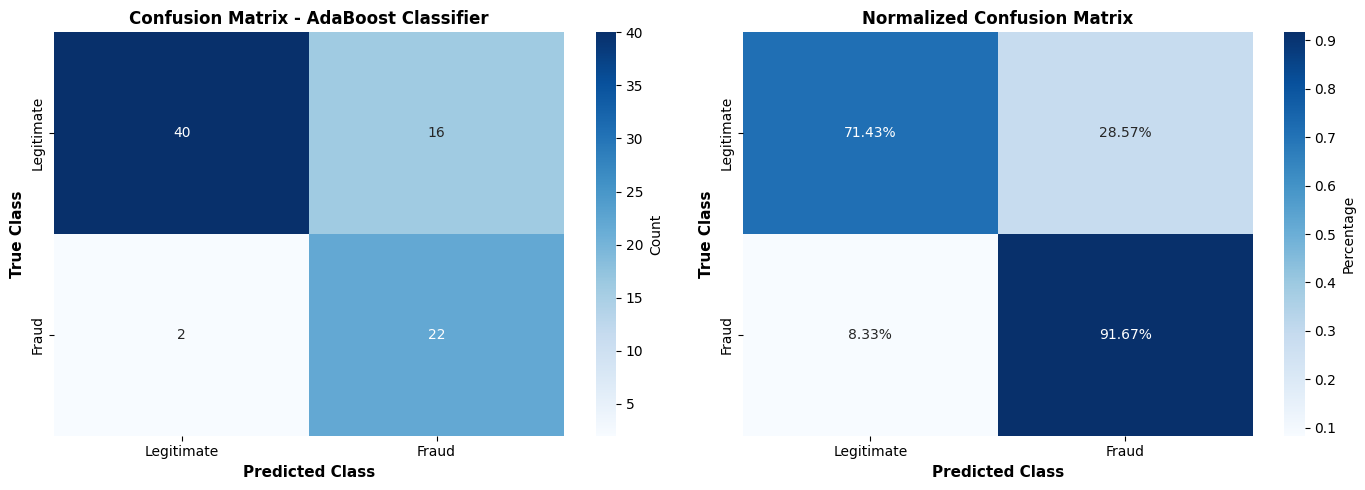

In [11]:
# Create confusion matrix heatmap
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

class_names = ['Legitimate', 'Fraud']

# Plot 1: Confusion Matrix Heatmap
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Count'})
axes[0].set_xlabel('Predicted Class', fontsize=11, weight='bold')
axes[0].set_ylabel('True Class', fontsize=11, weight='bold')
axes[0].set_title('Confusion Matrix - AdaBoost Classifier', fontsize=12, weight='bold')

# Plot 2: Normalized Confusion Matrix
conf_matrix_normalized = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis]
sns.heatmap(conf_matrix_normalized, annot=True, fmt='.2%', cmap='Blues', ax=axes[1],
            xticklabels=class_names, yticklabels=class_names, cbar_kws={'label': 'Percentage'})
axes[1].set_xlabel('Predicted Class', fontsize=11, weight='bold')
axes[1].set_ylabel('True Class', fontsize=11, weight='bold')
axes[1].set_title('Normalized Confusion Matrix', fontsize=12, weight='bold')

plt.tight_layout()
plt.show()

## Feature Importance

Extract and visualize feature importance from the AdaBoost model.

Feature Importance (Average across 50 estimators):
--------------------------------------------------
Transaction Amount       : 0.520000
Unusual Location         : 0.480000
Time Since Last          : 0.000000
Transaction Frequency    : 0.000000
--------------------------------------------------


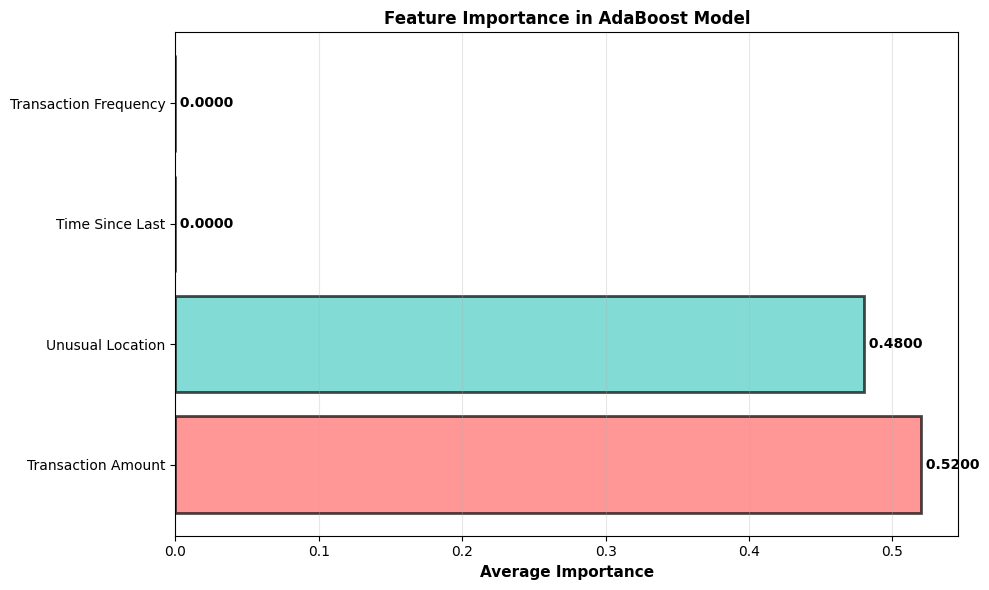

In [13]:
# Calculate average feature importance across all estimators
feature_names = ['Transaction Amount', 'Transaction Frequency', 'Time Since Last', 'Unusual Location']
feature_importances = np.zeros(len(feature_names))

for estimator in adaboost_model.estimators_:
    feature_importances += estimator.feature_importances_

feature_importances /= len(adaboost_model.estimators_)

# Sort by importance
sorted_idx = np.argsort(feature_importances)[::-1]

print(f"Feature Importance (Average across {len(adaboost_model.estimators_)} estimators):")
print("-" * 50)
for idx in sorted_idx:
    print(f"{feature_names[idx]:25s}: {feature_importances[idx]:.6f}")
print("-" * 50)

# Create visualization
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

colors = ['#FF6B6B' if i == sorted_idx[0] else '#4ECDC4' for i in range(len(feature_names))]
bars = ax.barh(range(len(feature_names)), feature_importances[sorted_idx], 
               color=[colors[i] for i in sorted_idx], alpha=0.7, edgecolor='black', linewidth=2)

ax.set_yticks(range(len(feature_names)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx])
ax.set_xlabel('Average Importance', fontsize=11, weight='bold')
ax.set_title('Feature Importance in AdaBoost Model', fontsize=12, weight='bold')
ax.grid(True, alpha=0.3, axis='x')

# Add value labels
for i, (bar, val) in enumerate(zip(bars, feature_importances[sorted_idx])):
    ax.text(val, bar.get_y() + bar.get_height()/2, f' {val:.4f}', 
            va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

## Metrics Visualization

Visualize model performance metrics.

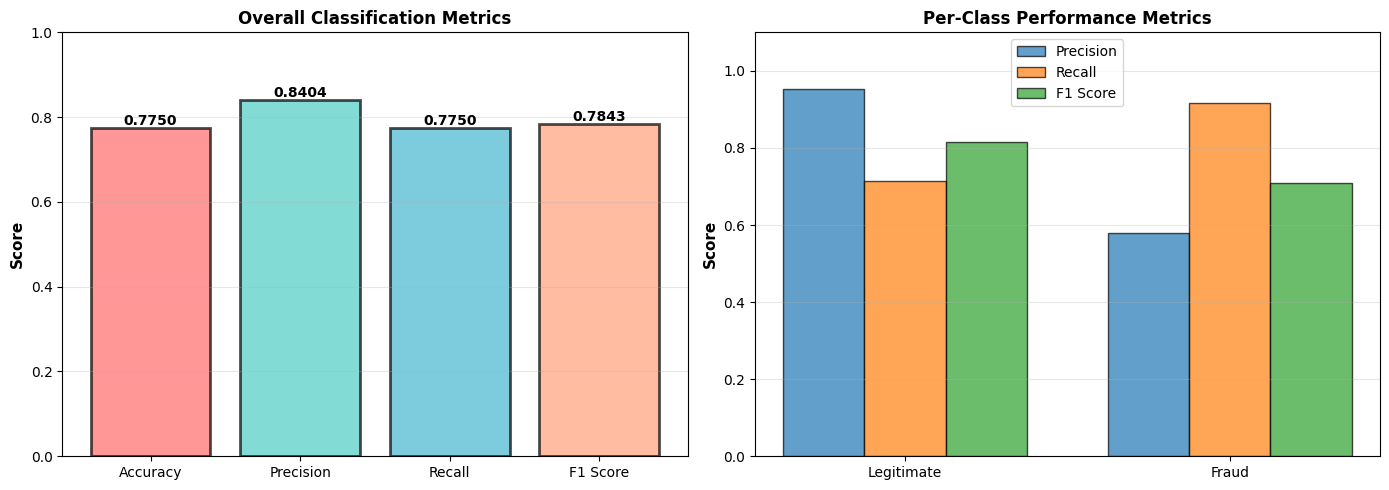

In [14]:
# Create metrics visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Classification Metrics Bar Chart
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#FFA07A']

bars = axes[0].bar(metrics_names, metrics_values, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
axes[0].set_ylabel('Score', fontsize=11, weight='bold')
axes[0].set_title('Overall Classification Metrics', fontsize=12, weight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(True, alpha=0.3, axis='y')

# Add value labels
for bar, val in zip(bars, metrics_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val, f'{val:.4f}', 
                ha='center', va='bottom', fontsize=10, weight='bold')

# Plot 2: Per-class Metrics
x = np.arange(2)
width = 0.25

axes[1].bar(x - width, precision_per_class, width, label='Precision', alpha=0.7, edgecolor='black')
axes[1].bar(x, recall_per_class, width, label='Recall', alpha=0.7, edgecolor='black')
axes[1].bar(x + width, f1_per_class, width, label='F1 Score', alpha=0.7, edgecolor='black')

axes[1].set_ylabel('Score', fontsize=11, weight='bold')
axes[1].set_title('Per-Class Performance Metrics', fontsize=12, weight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names)
axes[1].legend(loc='best', fontsize=10)
axes[1].set_ylim([0, 1.1])
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## Model Persistence and Predictions

Save the trained AdaBoost model and scaler for future use.

In [15]:
# Save the model and scaler
model_path = 'adaboost_fraud_model.joblib'
scaler_path = 'scaler_fraud.joblib'

joblib.dump(adaboost_model, model_path)
joblib.dump(scaler, scaler_path)

print(f"✓ AdaBoost model saved to: {model_path}")
print(f"✓ Scaler saved to: {scaler_path}")

# Example: Predict for new data
new_data = np.array([
    [100, 50, 5, 0.1],      # Likely Legitimate
    [4000, 2, 30, 0.9],     # Likely Fraud
    [500, 30, 10, 0.3]      # Likely Legitimate
])

new_data_scaled = scaler.transform(new_data)
new_predictions = adaboost_model.predict(new_data_scaled)
new_predictions_proba = adaboost_model.predict_proba(new_data_scaled)

print(f"\n{'='*80}")
print("PREDICTIONS FOR NEW DATA")
print(f"{'='*80}")
print(f"{'Amount':>10} | {'Frequency':>11} | {'Time Since':>11} | {'Unusual':>10} | {'Predicted':>12} | {'Confidence':>12}")
print("-" * 80)
for i in range(len(new_data)):
    confidence = np.max(new_predictions_proba[i])
    pred_name = 'Fraud' if new_predictions[i] == 1 else 'Legitimate'
    print(f"{new_data[i][0]:>10.0f} | {new_data[i][1]:>11.0f} | {new_data[i][2]:>11.1f} | {new_data[i][3]:>10.1f} | {pred_name:>12} | {confidence:>11.2%}")
print(f"{'='*80}")

print("\n✓ AdaBoost Classifier completed successfully!")

✓ AdaBoost model saved to: adaboost_fraud_model.joblib
✓ Scaler saved to: scaler_fraud.joblib

PREDICTIONS FOR NEW DATA
    Amount |   Frequency |  Time Since |    Unusual |    Predicted |   Confidence
--------------------------------------------------------------------------------
       100 |          50 |         5.0 |        0.1 |   Legitimate |      87.05%
      4000 |           2 |        30.0 |        0.9 |        Fraud |      51.34%
       500 |          30 |        10.0 |        0.3 |   Legitimate |      87.05%

✓ AdaBoost Classifier completed successfully!
